# 06 - Evaluation: Models Evaluation Comparison


In this notebook, we perform a comparative analysis of all trained models using:
- Metric distribution analysis and comparison (plots and summary statistics)
- Statistical significance testing (Corrected Resampled t-test)


## Import libraries and set the paths

In [1]:
from __future__ import annotations

import IPython.display as ipd
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

from fraud_dynamic_ensemble.config import MODELS_DIR, FIGURES_DIR
from fraud_dynamic_ensemble.evaluation.visual_evaluation import plot_model_distribution, plot_model_barplot
from fraud_dynamic_ensemble.evaluation.statistical_test_evaluation import compute_pairwise_corrected_resampled_ttest

2026-01-27 16:48:32.253 | INFO     | fraud_dynamic_ensemble.config:<module>:14 - PROJ_ROOT path is: /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Dynamic-Ensemble-Learning-for-Credit-Card-Fraud-Detection


In [2]:
EXPERIMENT_NAME = "CostSensitiveLearning___RandomizedSearchCV__niter_30__cv_5"

In [3]:
models_results_path: Path = MODELS_DIR / EXPERIMENT_NAME
print(f"Loading results at path:\n\t{models_results_path}")

Loading results at path:
	/home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Dynamic-Ensemble-Learning-for-Credit-Card-Fraud-Detection/models/CostSensitiveLearning___RandomizedSearchCV__niter_30__cv_5


In [4]:
FIGURES_MODELS_COMPARISON_DIR = FIGURES_DIR / "EV_models_comparison_evaluation"
FIGURES_MODELS_COMPARISON_DIR.mkdir(parents=True, exist_ok=True)

FIGURES_MODELS_COMPARISON_EXPERIMENT_DIR = FIGURES_MODELS_COMPARISON_DIR / EXPERIMENT_NAME
FIGURES_MODELS_COMPARISON_EXPERIMENT_DIR.mkdir(parents=True, exist_ok=True)

FIGURES_MULTIPLE_MODELS_EVALUATION_DIR = FIGURES_MODELS_COMPARISON_EXPERIMENT_DIR / "multiple_models_evaluation"
FIGURES_MULTIPLE_MODELS_EVALUATION_DIR.mkdir(parents=True, exist_ok=True)

In [5]:
pd.set_option("display.max_columns", None)
plt.rcParams.update({"font.size": 16})
sns.set_style("whitegrid")
sns.set_palette("tab10")

## Data Loading and Basic Overview

In [6]:
files = list(models_results_path.glob("*/generalization_metrics_summary.csv"))
generalization_df = pd.DataFrame()

print(f"Found {len(files)} files. Loading...")

if files:
    # Read and Concatenate
    # We use a generator expression inside concat for memory efficiency
    generalization_df = pd.concat((pd.read_csv(f) for f in files), ignore_index=True)

    print("Success! Combined dataframe shape:", generalization_df.shape)
else:
    print(f"No files found in {models_results_path.absolute()}")

Found 23 files. Loading...
Success! Combined dataframe shape: (2300, 25)


In [7]:
generalization_df

,experiment_name,iteration,fold,model,split,tp,tn,fp,fn,accuracy,precision,recall,f1,specificity,fpr,balanced_accuracy,geometric_mean,mcc,kappa,roc_auc,average_precision,score_time,fold_size,selected_features_indices,selected_features_names
0,CostSensitiveLearning___RandomizedSearchCV__ni...,1,1,KNOP,generalization,44,2415,45,3,0.980854,0.494382,0.936170,0.647059,0.981707,0.018293,0.958939,0.958668,0.672788,0.638181,0.971969,0.947270,9.851874,2507,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 16...","['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8..."
1,CostSensitiveLearning___RandomizedSearchCV__ni...,1,2,KNOP,generalization,40,2424,36,7,0.982848,0.526316,0.851064,0.650407,0.985366,0.014634,0.918215,0.915756,0.661678,0.642115,0.942350,0.824992,6.699205,2507,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14,...","['Amount_log1p', 'V1', 'V2', 'V3', 'V4', 'V5',..."
2,CostSensitiveLearning___RandomizedSearchCV__ni...,1,3,KNOP,generalization,39,2435,25,8,0.986837,0.609375,0.829787,0.702703,0.989837,0.010163,0.909812,0.906286,0.704823,0.696133,0.969495,0.856795,10.615066,2507,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 16...","['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8..."
3,CostSensitiveLearning___RandomizedSearchCV__ni...,1,4,KNOP,generalization,39,2439,21,8,0.988432,0.650000,0.829787,0.728972,0.991463,0.008537,0.910625,0.907030,0.728785,0.723151,0.940369,0.835085,8.374084,2507,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","['Amount_log1p', 'V1', 'V2', 'V3', 'V4', 'V5',..."
4,CostSensitiveLearning___RandomizedSearchCV__ni...,1,5,KNOP,generalization,41,2379,80,7,0.965297,0.338843,0.854167,0.485207,0.967466,0.032534,0.910817,0.909053,0.525351,0.470695,0.925054,0.850371,13.076344,2507,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 16...","['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2295,CostSensitiveLearning___RandomizedSearchCV__ni...,10,6,APriori,generalization,42,2379,80,6,0.965696,0.344262,0.875000,0.494118,0.967466,0.032534,0.921233,0.920072,0.536572,0.479823,0.961341,0.840800,7.278489,2507,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 16...","['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8..."
2296,CostSensitiveLearning___RandomizedSearchCV__ni...,10,7,APriori,generalization,39,2394,65,9,0.970483,0.375000,0.812500,0.513158,0.973566,0.026434,0.893033,0.889395,0.540214,0.500059,0.940215,0.726804,7.918153,2507,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","['Amount_log1p', 'V1', 'V2', 'V3', 'V4', 'V5',..."
2297,CostSensitiveLearning___RandomizedSearchCV__ni...,10,8,APriori,generalization,40,2364,95,7,0.959298,0.296296,0.851064,0.439560,0.961366,0.038634,0.906215,0.904535,0.488182,0.423521,0.950283,0.804343,14.182767,2506,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14,...","['Amount_log1p', 'V1', 'V2', 'V3', 'V4', 'V5',..."
2298,CostSensitiveLearning___RandomizedSearchCV__ni...,10,9,APriori,generalization,38,2420,39,9,0.980846,0.493506,0.808511,0.612903,0.984140,0.015860,0.896325,0.892013,0.623090,0.603672,0.912103,0.727781,10.022541,2506,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","['Amount_log1p', 'V1', 'V2', 'V3', 'V4', 'V5',..."


## Fix the metrics and model to evaluate and compare

In [8]:
metrics_to_analyze = [
    "balanced_accuracy",
    "mcc",
    "average_precision",
    "f1",
]
print(f"Selected metrics:\n\t{metrics_to_analyze}")

Selected metrics:
	['balanced_accuracy', 'mcc', 'average_precision', 'f1']


In [9]:
models_to_analyze = ["APriori", "APosteriori", "KNORAE", "MLPClassifier", ]
print(f"Selected models:\n\t{models_to_analyze}")

generalization_df = generalization_df[generalization_df["model"].isin(models_to_analyze)]
generalization_df

Selected models:
	['APriori', 'APosteriori', 'KNORAE', 'MLPClassifier']


,experiment_name,iteration,fold,model,split,tp,tn,fp,fn,accuracy,precision,recall,f1,specificity,fpr,balanced_accuracy,geometric_mean,mcc,kappa,roc_auc,average_precision,score_time,fold_size,selected_features_indices,selected_features_names
100,CostSensitiveLearning___RandomizedSearchCV__ni...,1,1,KNORAE,generalization,44,2394,66,3,0.972477,0.400000,0.936170,0.560510,0.973171,0.026829,0.954670,0.954491,0.602161,0.548652,0.962852,0.539176,4.523284,2507,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14,...","['Amount_log1p', 'V1', 'V2', 'V3', 'V4', 'V5',..."
101,CostSensitiveLearning___RandomizedSearchCV__ni...,1,2,KNORAE,generalization,40,2425,35,7,0.983247,0.533333,0.851064,0.655738,0.985772,0.014228,0.918418,0.915945,0.666261,0.647615,0.903736,0.697552,6.079954,2507,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14,...","['Amount_log1p', 'V1', 'V2', 'V3', 'V4', 'V5',..."
102,CostSensitiveLearning___RandomizedSearchCV__ni...,1,3,KNORAE,generalization,40,2407,53,7,0.976067,0.430108,0.851064,0.571429,0.978455,0.021545,0.914760,0.912539,0.595296,0.560481,0.932659,0.730522,9.674312,2507,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 16...","['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8..."
103,CostSensitiveLearning___RandomizedSearchCV__ni...,1,4,KNORAE,generalization,37,2386,74,10,0.966494,0.333333,0.787234,0.468354,0.969919,0.030081,0.878576,0.873815,0.499224,0.453971,0.923698,0.566524,8.583318,2507,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","['Amount_log1p', 'V1', 'V2', 'V3', 'V4', 'V5',..."
104,CostSensitiveLearning___RandomizedSearchCV__ni...,1,5,KNORAE,generalization,35,2392,67,13,0.968089,0.343137,0.729167,0.466667,0.972753,0.027247,0.850960,0.842199,0.486889,0.452408,0.894173,0.475590,12.876175,2507,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 16...","['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2295,CostSensitiveLearning___RandomizedSearchCV__ni...,10,6,APriori,generalization,42,2379,80,6,0.965696,0.344262,0.875000,0.494118,0.967466,0.032534,0.921233,0.920072,0.536572,0.479823,0.961341,0.840800,7.278489,2507,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 16...","['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8..."
2296,CostSensitiveLearning___RandomizedSearchCV__ni...,10,7,APriori,generalization,39,2394,65,9,0.970483,0.375000,0.812500,0.513158,0.973566,0.026434,0.893033,0.889395,0.540214,0.500059,0.940215,0.726804,7.918153,2507,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","['Amount_log1p', 'V1', 'V2', 'V3', 'V4', 'V5',..."
2297,CostSensitiveLearning___RandomizedSearchCV__ni...,10,8,APriori,generalization,40,2364,95,7,0.959298,0.296296,0.851064,0.439560,0.961366,0.038634,0.906215,0.904535,0.488182,0.423521,0.950283,0.804343,14.182767,2506,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14,...","['Amount_log1p', 'V1', 'V2', 'V3', 'V4', 'V5',..."
2298,CostSensitiveLearning___RandomizedSearchCV__ni...,10,9,APriori,generalization,38,2420,39,9,0.980846,0.493506,0.808511,0.612903,0.984140,0.015860,0.896325,0.892013,0.623090,0.603672,0.912103,0.727781,10.022541,2506,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","['Amount_log1p', 'V1', 'V2', 'V3', 'V4', 'V5',..."


## Model Comparison (Distribution Analysis)

### Objective
To compare the performance distribution of all models for a specific metric on a targeted data split (e.g., Generalization or Resubstitution).

### Methodology
We generate a **distribution plot** and a **statistical report** for the selected metric and split:
* **Scope:** Parametrizable (Default: **Generalization**).
* **Visualization:**
    * **Boxplot:** Displays the median, Interquartile Range (IQR), and spread.
    * **Strip Plot:** Overlays raw data points (100 folds) to visualize density.
* **Statistics:** A summary table (Mean, Std, Min, Max) is displayed and saved to quantify the visual results.
* **Sorting:** Models are sorted **Alphabetically** to ensure consistent ordering across different plots.
* **Scale:** Fixed to $0.0 - 1.0$ (or customized based on metric range).

### Interpretation Guide
* **Box Height:** Higher is better for standard metrics (e.g., F1, MCC). Lower is better for error metrics.
* **Box Size (IQR):** A short box implies high stability (low variance). A tall box implies the model behavior changes drastically depending on the data fold.
* **Split Comparison:** By generating this plot for both 'resubstitution' and 'generalization', one can visually confirm overfitting (if the Resubstitution box is high/tight while the Generalization box is low/wide).


DISTRIBUTION ANALYSIS: BALANCED_ACCURACY (GENERALIZATION)


,balanced_accuracy_count,balanced_accuracy_mean,balanced_accuracy_std,balanced_accuracy_min,balanced_accuracy_25%,balanced_accuracy_50%,balanced_accuracy_75%,balanced_accuracy_max
model,,,,,,,,
APosteriori,100.0,0.913821,0.028063,0.829381,0.894161,0.913674,0.932436,0.976893
APriori,100.0,0.900301,0.027235,0.831275,0.883242,0.901270,0.917614,0.957109
KNORAE,100.0,0.900401,0.030767,0.818608,0.881510,0.904253,0.919651,0.970390
MLPClassifier,100.0,0.916570,0.028732,0.840019,0.895630,0.916463,0.935967,0.978317


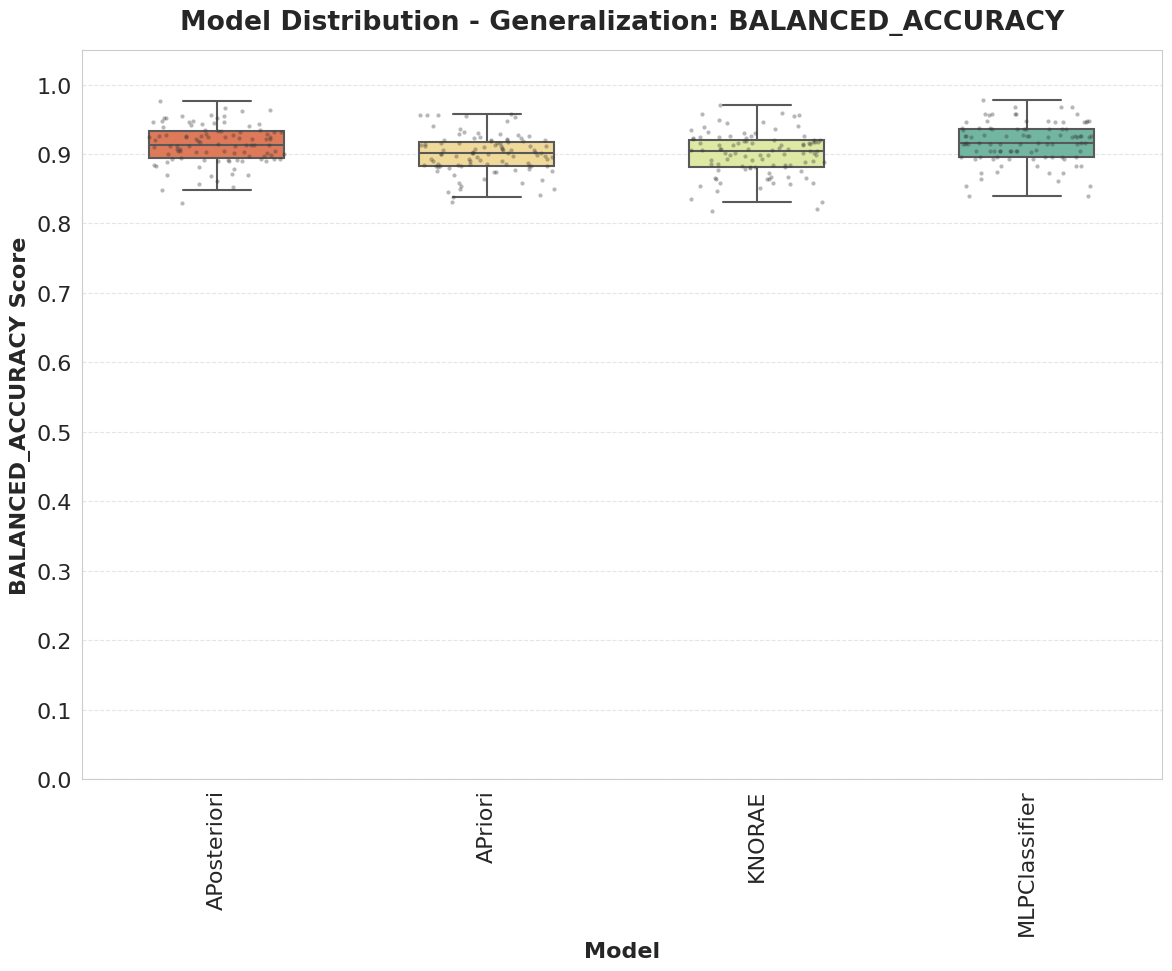


DISTRIBUTION ANALYSIS: MCC (GENERALIZATION)


,mcc_count,mcc_mean,mcc_std,mcc_min,mcc_25%,mcc_50%,mcc_75%,mcc_max
model,,,,,,,,
APosteriori,100.0,0.751290,0.088530,0.528350,0.690578,0.761362,0.825398,0.909667
APriori,100.0,0.551497,0.061642,0.395700,0.514267,0.547518,0.594519,0.713094
KNORAE,100.0,0.555929,0.070704,0.419003,0.499230,0.558073,0.605939,0.720993
MLPClassifier,100.0,0.891414,0.034101,0.797439,0.872622,0.897751,0.911642,0.956633


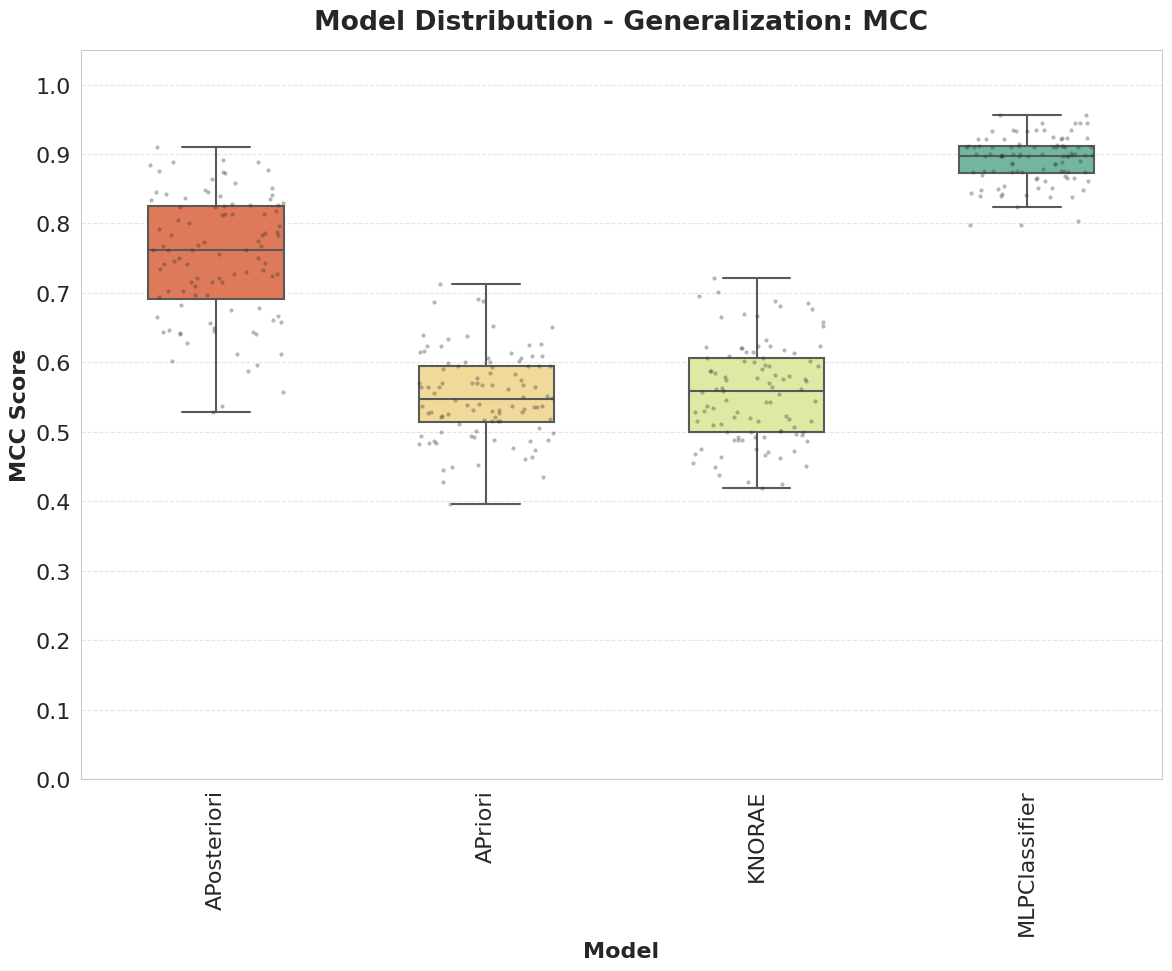


DISTRIBUTION ANALYSIS: AVERAGE_PRECISION (GENERALIZATION)


,average_precision_count,average_precision_mean,average_precision_std,average_precision_min,average_precision_25%,average_precision_50%,average_precision_75%,average_precision_max
model,,,,,,,,
APosteriori,100.0,0.814930,0.055799,0.665398,0.784717,0.817461,0.850079,0.924672
APriori,100.0,0.743435,0.079787,0.500101,0.701889,0.754898,0.801359,0.882670
KNORAE,100.0,0.625810,0.117292,0.341234,0.532843,0.626424,0.731221,0.839024
MLPClassifier,100.0,0.896752,0.037141,0.760653,0.873548,0.901019,0.921333,0.977138


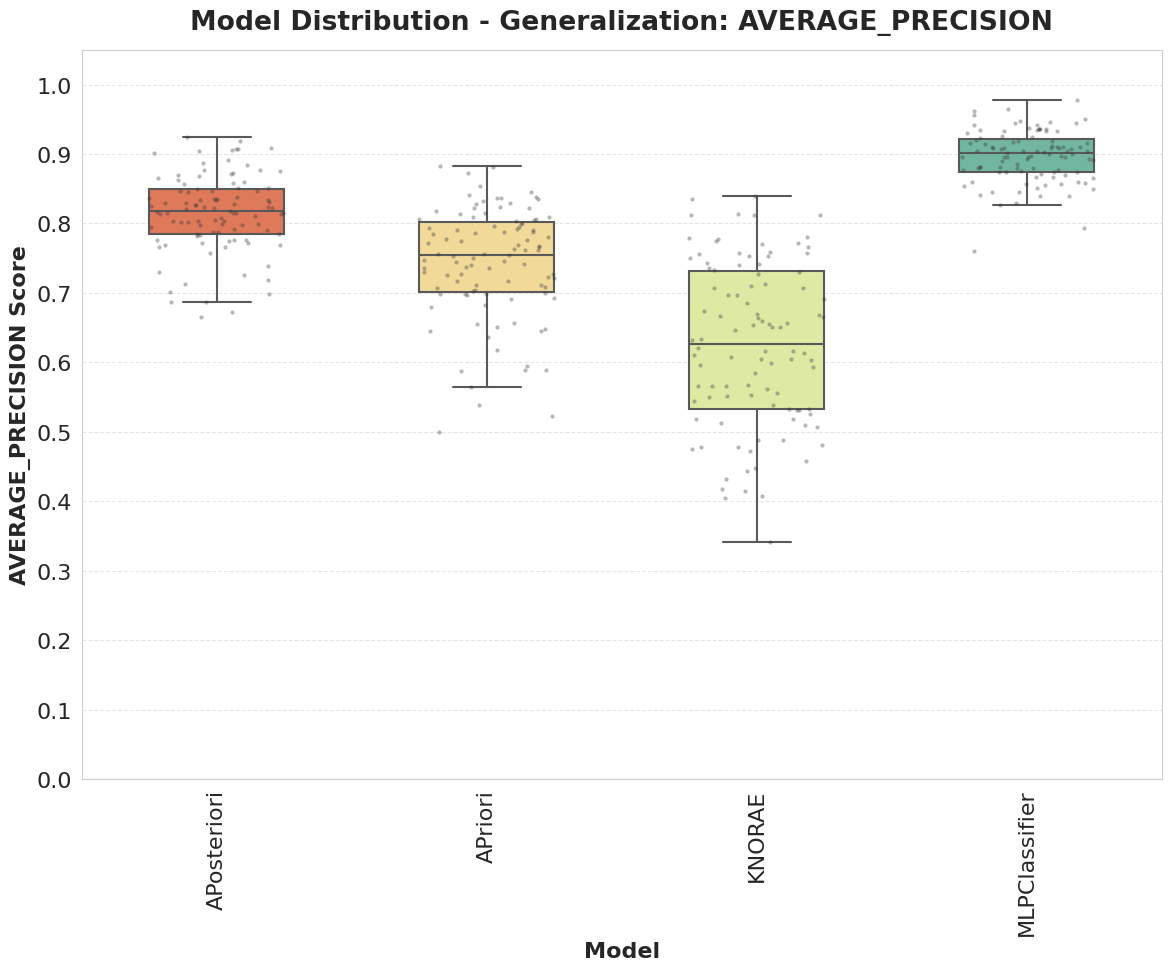


DISTRIBUTION ANALYSIS: F1 (GENERALIZATION)


,f1_count,f1_mean,f1_std,f1_min,f1_25%,f1_50%,f1_75%,f1_max
model,,,,,,,,
APosteriori,100.0,0.747549,0.095723,0.493827,0.683908,0.761387,0.827760,0.909091
APriori,100.0,0.522620,0.071331,0.316981,0.476439,0.518121,0.575739,0.705882
KNORAE,100.0,0.527830,0.080077,0.371429,0.463576,0.529417,0.578712,0.711864
MLPClassifier,100.0,0.890454,0.035405,0.790123,0.870588,0.896552,0.913043,0.957447


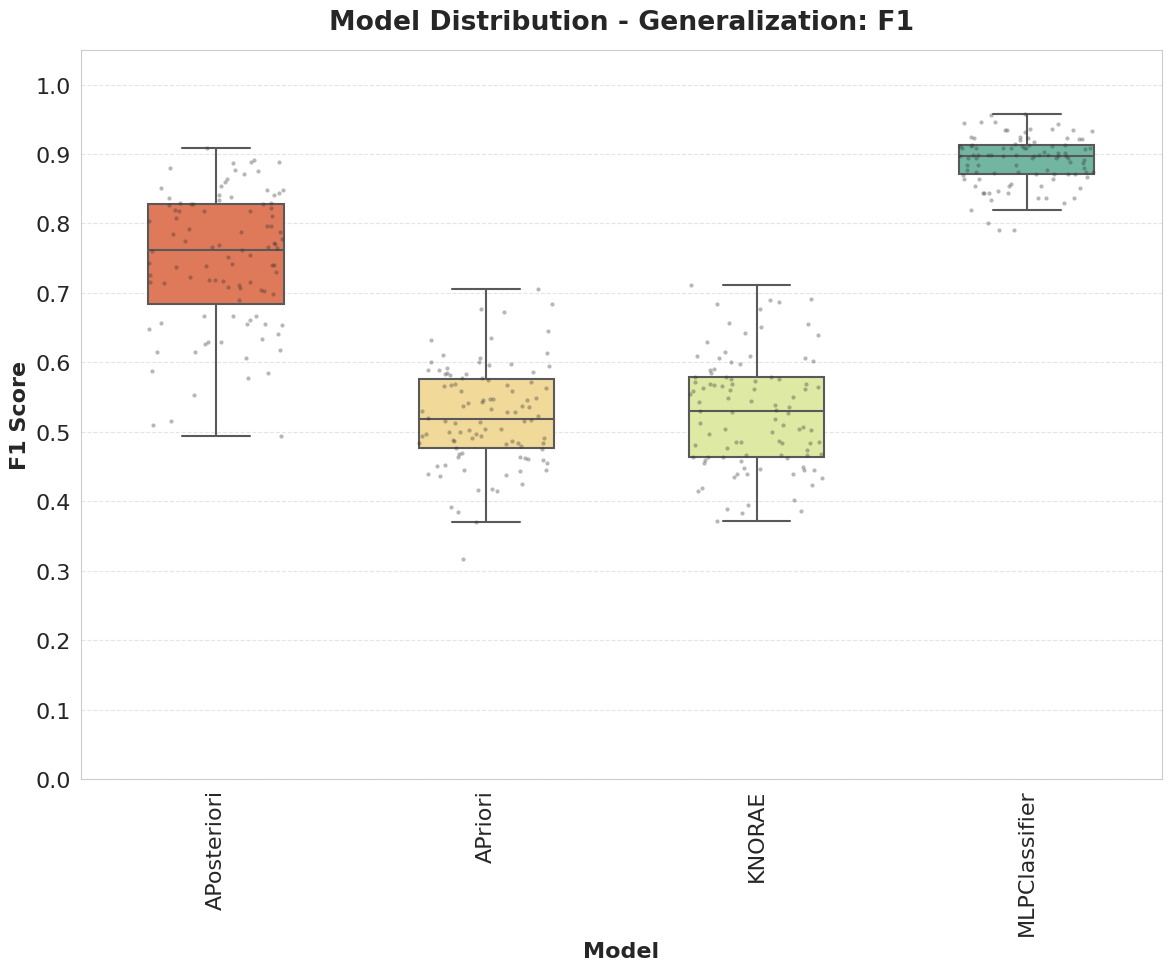


FINAL DISTRIBUTION SUMMARY


,balanced_accuracy_count,balanced_accuracy_mean,balanced_accuracy_std,balanced_accuracy_min,balanced_accuracy_25%,balanced_accuracy_50%,balanced_accuracy_75%,balanced_accuracy_max,mcc_count,mcc_mean,mcc_std,mcc_min,mcc_25%,mcc_50%,mcc_75%,mcc_max,average_precision_count,average_precision_mean,average_precision_std,average_precision_min,average_precision_25%,average_precision_50%,average_precision_75%,average_precision_max,f1_count,f1_mean,f1_std,f1_min,f1_25%,f1_50%,f1_75%,f1_max
model,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
APosteriori,100.0,0.913821,0.028063,0.829381,0.894161,0.913674,0.932436,0.976893,100.0,0.751290,0.088530,0.528350,0.690578,0.761362,0.825398,0.909667,100.0,0.814930,0.055799,0.665398,0.784717,0.817461,0.850079,0.924672,100.0,0.747549,0.095723,0.493827,0.683908,0.761387,0.827760,0.909091
APriori,100.0,0.900301,0.027235,0.831275,0.883242,0.901270,0.917614,0.957109,100.0,0.551497,0.061642,0.395700,0.514267,0.547518,0.594519,0.713094,100.0,0.743435,0.079787,0.500101,0.701889,0.754898,0.801359,0.882670,100.0,0.522620,0.071331,0.316981,0.476439,0.518121,0.575739,0.705882
KNORAE,100.0,0.900401,0.030767,0.818608,0.881510,0.904253,0.919651,0.970390,100.0,0.555929,0.070704,0.419003,0.499230,0.558073,0.605939,0.720993,100.0,0.625810,0.117292,0.341234,0.532843,0.626424,0.731221,0.839024,100.0,0.527830,0.080077,0.371429,0.463576,0.529417,0.578712,0.711864
MLPClassifier,100.0,0.916570,0.028732,0.840019,0.895630,0.916463,0.935967,0.978317,100.0,0.891414,0.034101,0.797439,0.872622,0.897751,0.911642,0.956633,100.0,0.896752,0.037141,0.760653,0.873548,0.901019,0.921333,0.977138,100.0,0.890454,0.035405,0.790123,0.870588,0.896552,0.913043,0.957447


In [10]:
# List to store individual metric reports
metric_reports = []

for metric in metrics_to_analyze:
    report = plot_model_distribution(df=generalization_df,
                                     metric_name=metric,
                                     save_path=FIGURES_MULTIPLE_MODELS_EVALUATION_DIR,
                                     split_name="generalization")

    if report is not None:
        metric_reports.append(report)

# --- Final Aggregation ---
if metric_reports:
    # Concatenate all reports along columns (axis=1)
    # Since all reports share the same Index (Model Name), they will align automatically
    final_summary_df: pd.DataFrame = pd.concat(metric_reports, axis=1)

    print(f"\n{'='*80}\nFINAL DISTRIBUTION SUMMARY\n{'='*80}")
    ipd.display(final_summary_df)

    final_csv_path = FIGURES_MULTIPLE_MODELS_EVALUATION_DIR / "distribution_boxplot_summary.csv"
    final_summary_df.to_csv(final_csv_path)
else:
    print("No reports were generated.")

## Model Comparison (Mean Performance & Stability)

### Objective
To summarize the central tendency (Mean) and reliability (Standard Deviation) of each model on the specified data split.

### Methodology
We generate a **Bar Chart with Error Bars** and a **Summary Table**:
* **Calculation:** We compute the **Mean** and **Standard Deviation** (SD) across all data partitions (pooled Iterations × Folds).
    * **Bar Height:** Represents the Mean Score.
    * **Error Bar:** Represents ±1 Standard Deviation.
* **Formatted Report:** Statistics are aggregated into a concise "Mean ± SD" format (e.g., $0.852 \pm 0.012$) to facilitate quick comparison of stability.
* **Sorting:** Models are sorted **Alphabetically** for consistent cross-referencing.
* **Scale:** Fixed to $0.0 - 1.0$ (or customized) to ensure comparability.

### Interpretation Guide
* **Higher Bar:** Better average performance.
* **Shorter Error Bar:** More stable/reliable model.
* **Overlapping Error Bars:** If the error bars of two models overlap significantly, their performance difference may not be statistically significant (requires the t-test heatmap for confirmation).


BARPLOT ANALYSIS: BALANCED_ACCURACY (GENERALIZATION)


,balanced_accuracy
model,
APosteriori,0.914 ± 0.028
APriori,0.900 ± 0.027
KNORAE,0.900 ± 0.031
MLPClassifier,0.917 ± 0.029


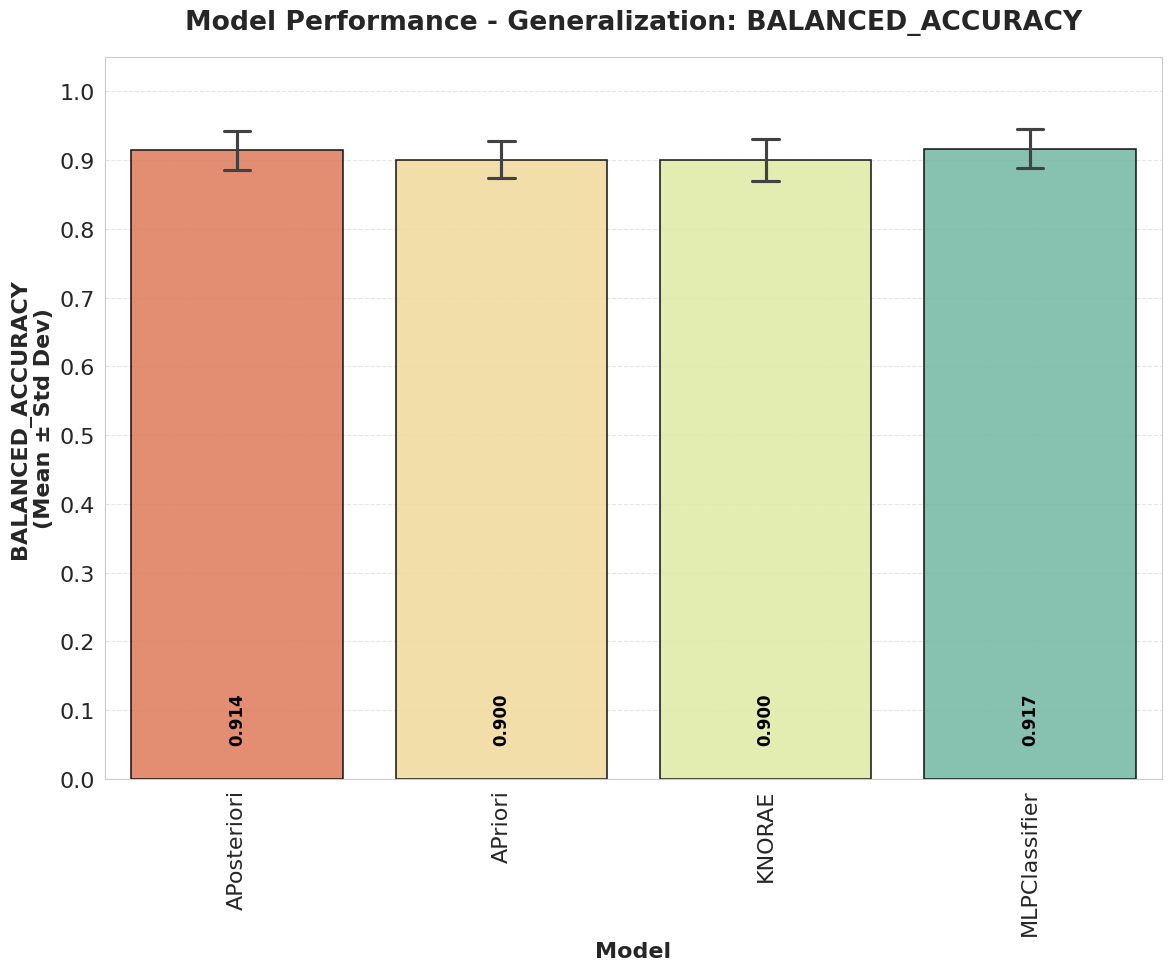


BARPLOT ANALYSIS: MCC (GENERALIZATION)


,mcc
model,
APosteriori,0.751 ± 0.089
APriori,0.551 ± 0.062
KNORAE,0.556 ± 0.071
MLPClassifier,0.891 ± 0.034


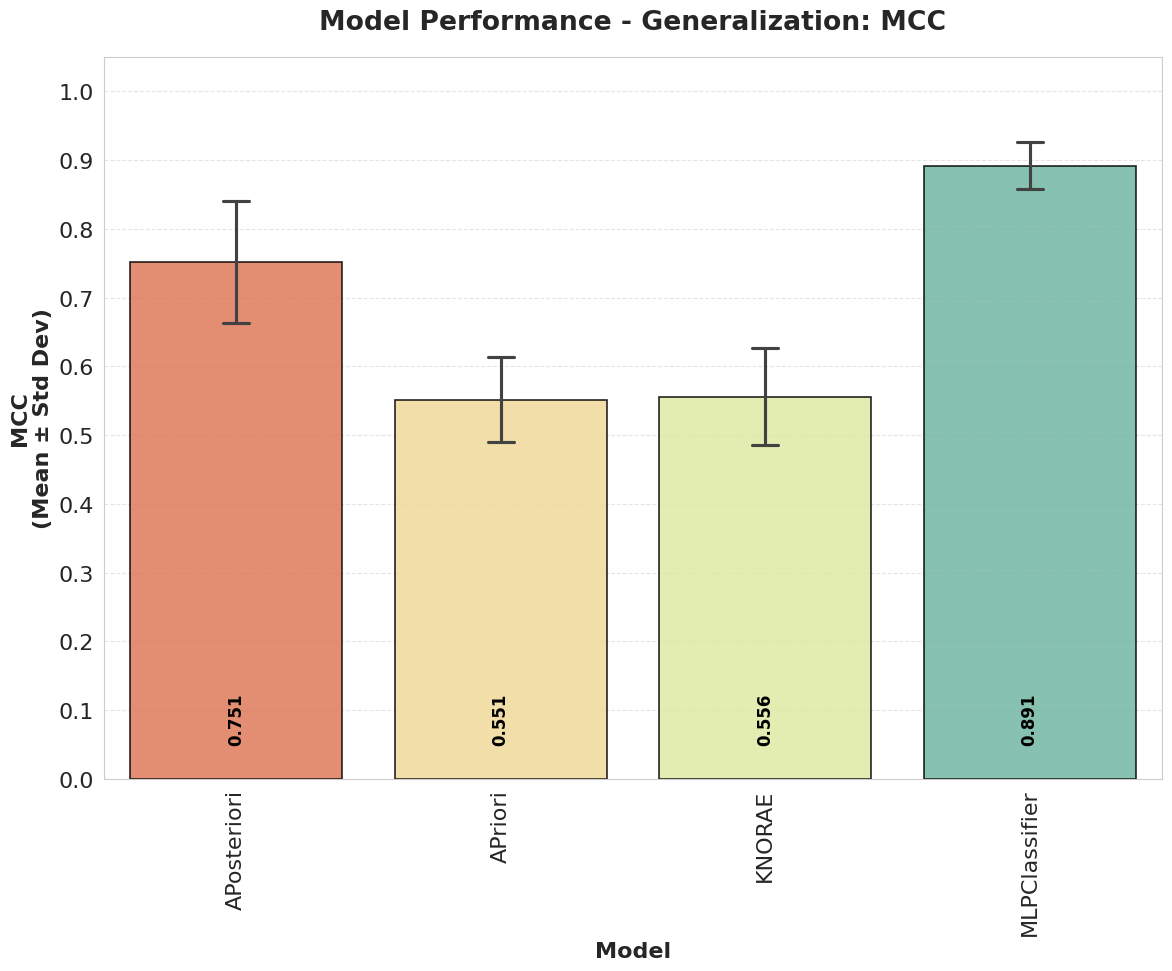


BARPLOT ANALYSIS: AVERAGE_PRECISION (GENERALIZATION)


,average_precision
model,
APosteriori,0.815 ± 0.056
APriori,0.743 ± 0.080
KNORAE,0.626 ± 0.117
MLPClassifier,0.897 ± 0.037


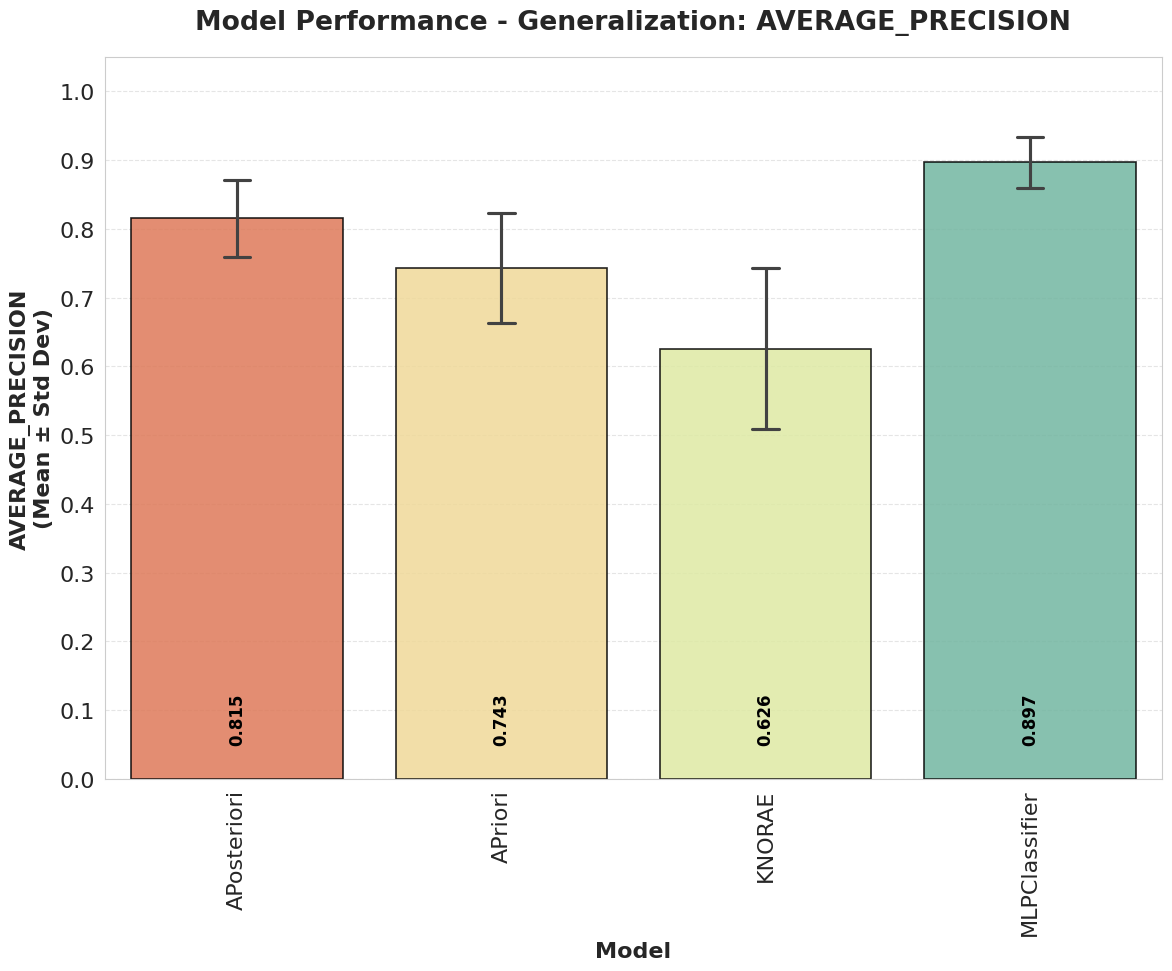


BARPLOT ANALYSIS: F1 (GENERALIZATION)


,f1
model,
APosteriori,0.748 ± 0.096
APriori,0.523 ± 0.071
KNORAE,0.528 ± 0.080
MLPClassifier,0.890 ± 0.035


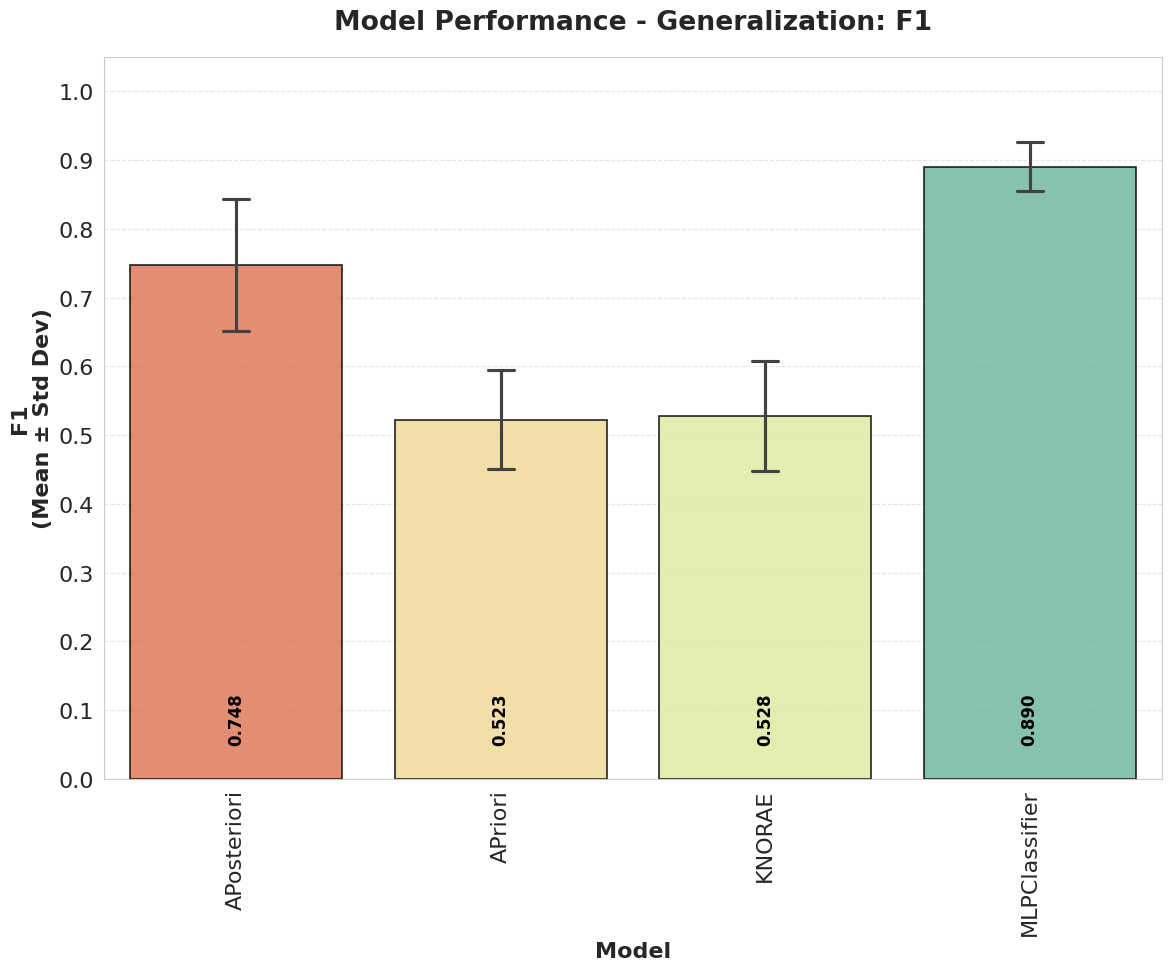


FINAL PERFORMANCE SUMMARY (Mean ± Std)


,balanced_accuracy,mcc,average_precision,f1
model,,,,
APosteriori,0.914 ± 0.028,0.751 ± 0.089,0.815 ± 0.056,0.748 ± 0.096
APriori,0.900 ± 0.027,0.551 ± 0.062,0.743 ± 0.080,0.523 ± 0.071
KNORAE,0.900 ± 0.031,0.556 ± 0.071,0.626 ± 0.117,0.528 ± 0.080
MLPClassifier,0.917 ± 0.029,0.891 ± 0.034,0.897 ± 0.037,0.890 ± 0.035


In [11]:
# List to store individual metric reports
metric_reports = []

for metric in metrics_to_analyze:
    report = plot_model_barplot(df=generalization_df,
                                metric_name=metric,
                                save_path=FIGURES_MULTIPLE_MODELS_EVALUATION_DIR,
                                split_name="generalization")

    if report is not None:
        metric_reports.append(report)

# --- Final Aggregation ---
if metric_reports:
    # Concatenate all reports along columns (axis=1)
    # Since all reports share the same Index (Model Name), they will align automatically
    final_summary_df: pd.DataFrame = pd.concat(metric_reports, axis=1)

    print(f"\n{'='*80}\nFINAL PERFORMANCE SUMMARY (Mean ± Std)\n{'='*80}")
    ipd.display(final_summary_df)

    final_csv_path = FIGURES_MULTIPLE_MODELS_EVALUATION_DIR / "distribution_barplot_summary.csv"
    final_summary_df.to_csv(final_csv_path)
else:
    print("No reports were generated.")

## Model Comparison & Statistical Significance Testing

### Objective
To definitively determine which models perform better than others by moving beyond simple average scores. We aim to identify **statistically significant differences** between model pairs, ensuring that observed performance gains are real and not merely artifacts of random data splitting.

### Methodology: Corrected Resampled t-test
Standard statistical tests (like the independent t-test) assume that data samples are independent. However, in Cross-Validation, training sets overlap significantly (e.g., 90% overlap in 10-fold CV), violating this assumption and leading to underestimated variance and high False Positive rates (Type I errors).

To address this, we employ the **Corrected Resampled t-test** proposed by Nadeau and Bengio (2003). This test adjusts the variance to account for the correlation between training sets and the ratio of testing to training samples.

The corrected t-statistic is calculated as:

$$t = \frac{\mu_{diff}}{\sqrt{\sigma_{diff}^2 \cdot (\frac{1}{n} + \frac{n_{test}}{n_{train}})}}$$

Where:
* $\mu_{diff}$: Mean difference in scores between Model A and Model B.
* $\sigma_{diff}^2$: Variance of the differences.
* $n$: Number of evaluations (Iterations $\times$ Folds).
* $\frac{n_{test}}{n_{train}}$: Correction factor for the overlap between training sets.

### Visualization: Pairwise Significance Heatmap
We visualize the results using a **Significance Heatmap** for each metric. This matrix displays the outcome of the hypothesis test for every pair of models based on the p-value.

* **Rows & Columns:** Each cell represents the comparison between the model on the row and the model on the column.
* **Color Coding:**
    * **Blue Cells ($p < 0.05$):** Indicate a **statistically significant difference**. Darker blues represent higher confidence (lower p-values, e.g., $p < 0.001$).
        * *Note:* This color confirms the models are *different*, but you must check the mean scores (or the CSV `Mean_Diff`) to see which one is *better*.
    * **Orange/Red Cells (NS):** Indicate **No Significant Difference**. The models perform statistically similarly, meaning any difference in their average scores is likely due to chance.

### Interpretation Guide
1.  **Identify "Cliques":** Look for blocks of **Orange (NS)** cells. These represent groups of models that are statistically indistinguishable from each other.
2.  **Verify Improvements:** If a high-scoring model has a **Blue** cell when compared to a baseline model, the improvement is real and statistically significant.
3.  **Symmetry:** The chart is symmetric. A Blue cell at (Row A, Col B) means A and B are significantly different. Use the `df_comparisons` table to confirm if A > B or B > A.


CORRECTED RESAMPLED t-TEST ANALYSIS (Pairwise): BALANCED_ACCURACY
Comparing 'APosteriori' (mean=0.914) vs 'APriori' (mean=0.900)
  p-value: 0.3067 (t=1.0274) -> NOT significant
--------------------------------------------------------------------------------
Comparing 'APosteriori' (mean=0.914) vs 'KNORAE' (mean=0.900)
  p-value: 0.3371 (t=0.9647) -> NOT significant
--------------------------------------------------------------------------------
Comparing 'APosteriori' (mean=0.914) vs 'MLPClassifier' (mean=0.917)
  p-value: 0.8575 (t=-0.1801) -> NOT significant
--------------------------------------------------------------------------------
Comparing 'APriori' (mean=0.900) vs 'APosteriori' (mean=0.914)
  p-value: 0.3067 (t=-1.0274) -> NOT significant
--------------------------------------------------------------------------------
Comparing 'APriori' (mean=0.900) vs 'KNORAE' (mean=0.900)
  p-value: 0.9921 (t=-0.0100) -> NOT significant
---------------------------------------------------

/home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Dynamic-Ensemble-Learning-for-Credit-Card-Fraud-Detection/fraud_dynamic_ensemble/evaluation/statistical_test_evaluation.py:314: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.sort_values(by=["model"], inplace=True)


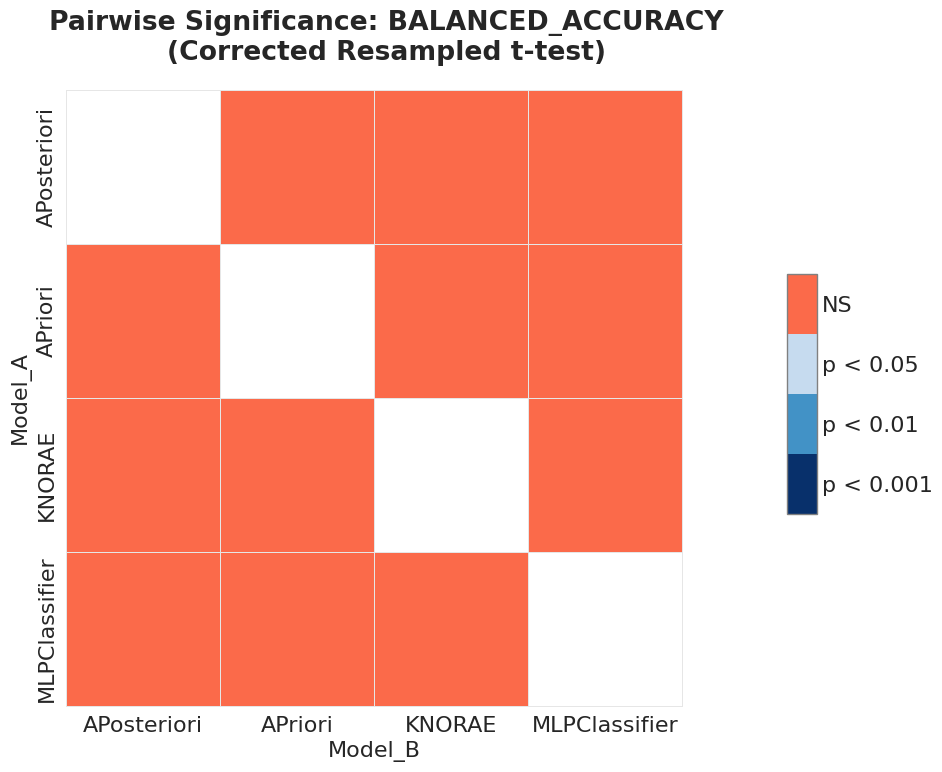

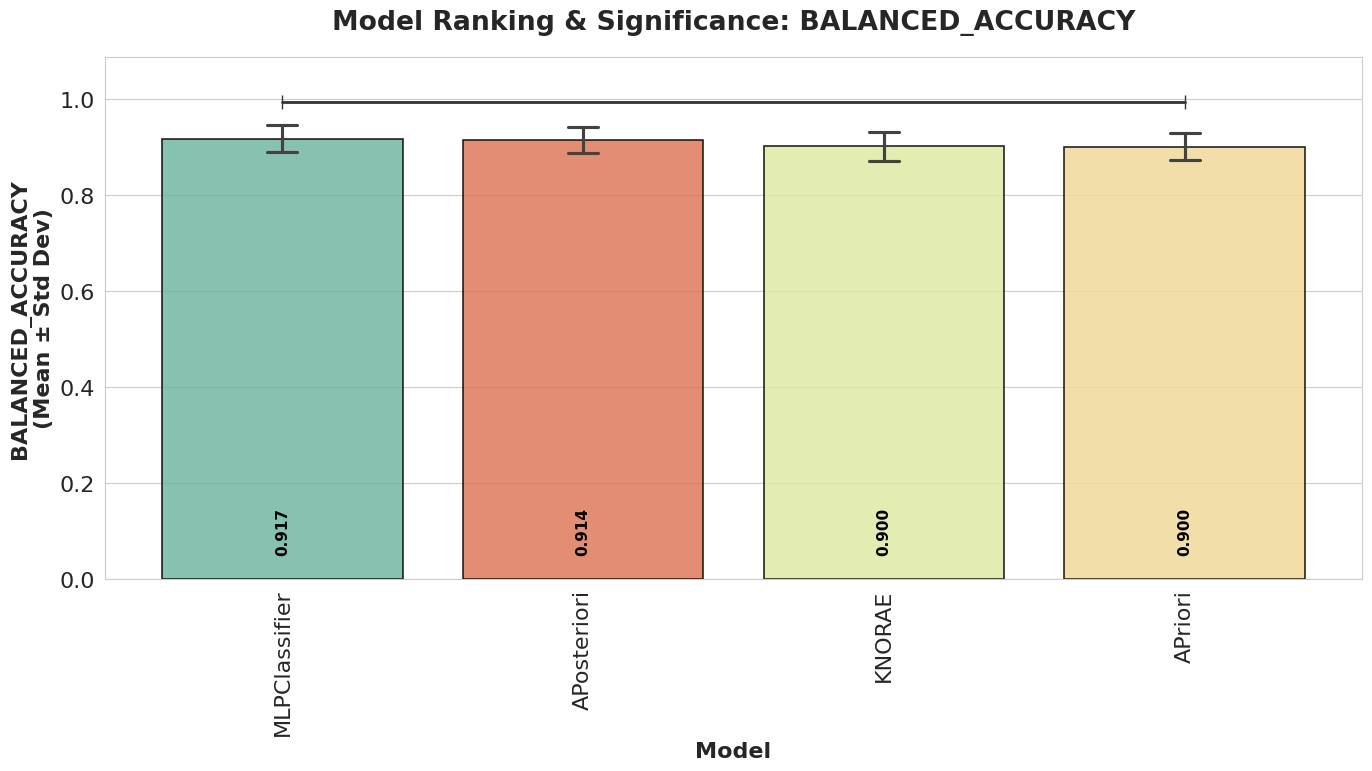


CORRECTED RESAMPLED t-TEST ANALYSIS (Pairwise): MCC
Comparing 'APosteriori' (mean=0.751) vs 'APriori' (mean=0.551)
  p-value: 0.0000 (t=4.8248) -> Statistically SIGNIFICANT
--------------------------------------------------------------------------------
Comparing 'APosteriori' (mean=0.751) vs 'KNORAE' (mean=0.556)
  p-value: 0.0000 (t=4.8401) -> Statistically SIGNIFICANT
--------------------------------------------------------------------------------
Comparing 'APosteriori' (mean=0.751) vs 'MLPClassifier' (mean=0.891)
  p-value: 0.0001 (t=-4.1390) -> Statistically SIGNIFICANT
--------------------------------------------------------------------------------
Comparing 'APriori' (mean=0.551) vs 'APosteriori' (mean=0.751)
  p-value: 0.0000 (t=-4.8248) -> Statistically SIGNIFICANT
--------------------------------------------------------------------------------
Comparing 'APriori' (mean=0.551) vs 'KNORAE' (mean=0.556)
  p-value: 0.8808 (t=-0.1504) -> NOT significant
-------------------------

/home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Dynamic-Ensemble-Learning-for-Credit-Card-Fraud-Detection/fraud_dynamic_ensemble/evaluation/statistical_test_evaluation.py:314: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.sort_values(by=["model"], inplace=True)


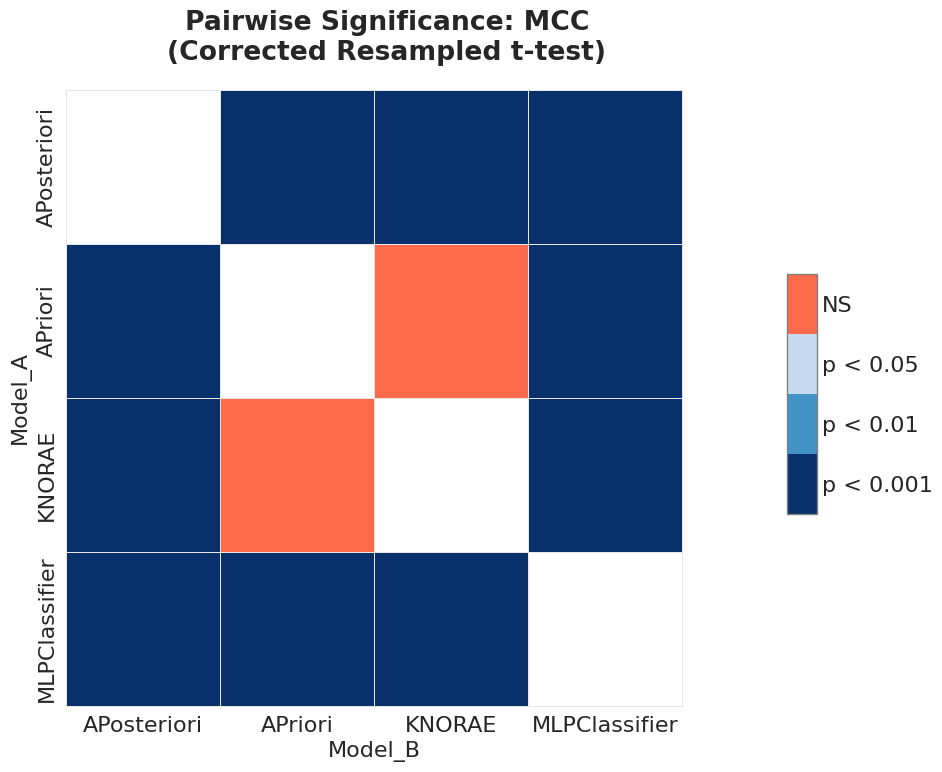

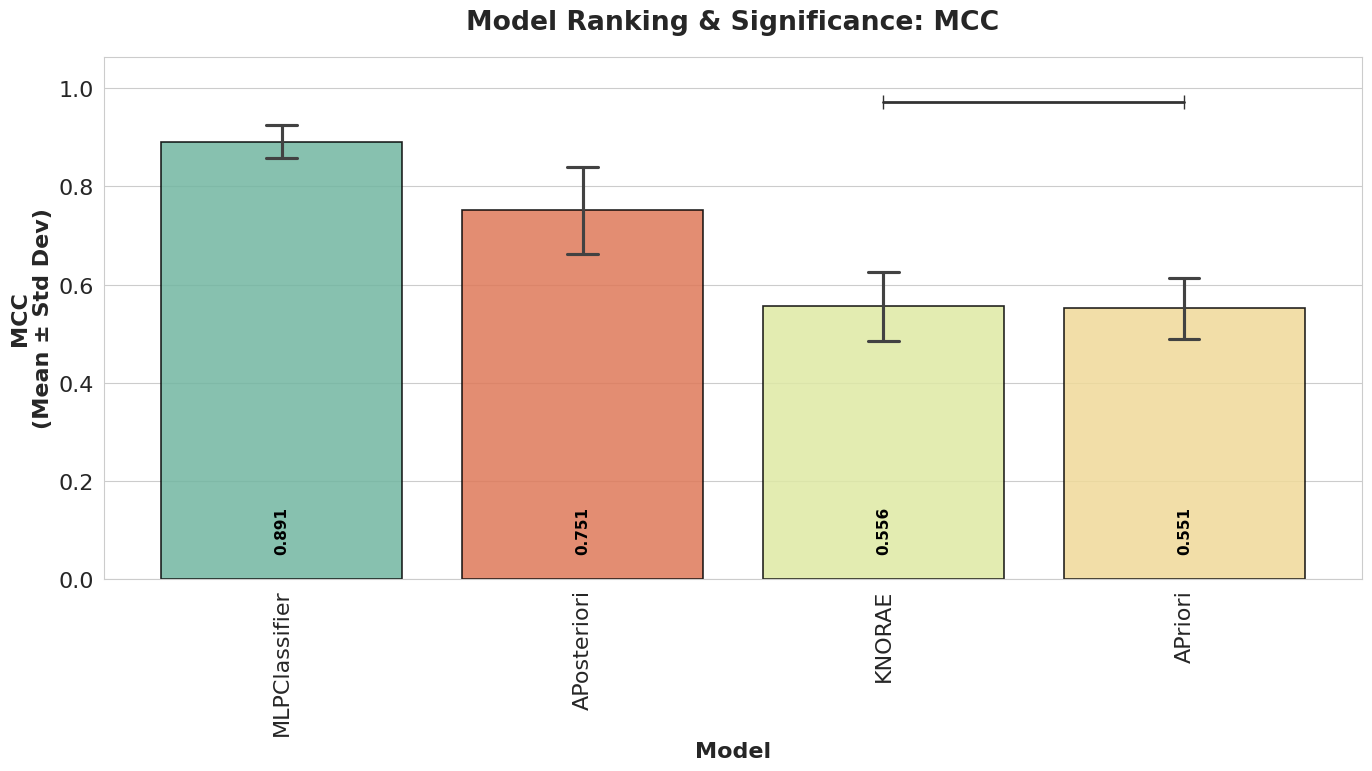


CORRECTED RESAMPLED t-TEST ANALYSIS (Pairwise): AVERAGE_PRECISION
Comparing 'APosteriori' (mean=0.815) vs 'APriori' (mean=0.743)
  p-value: 0.0397 (t=2.0847) -> Statistically SIGNIFICANT
--------------------------------------------------------------------------------
Comparing 'APosteriori' (mean=0.815) vs 'KNORAE' (mean=0.626)
  p-value: 0.0000 (t=4.4438) -> Statistically SIGNIFICANT
--------------------------------------------------------------------------------
Comparing 'APosteriori' (mean=0.815) vs 'MLPClassifier' (mean=0.897)
  p-value: 0.0002 (t=-3.8643) -> Statistically SIGNIFICANT
--------------------------------------------------------------------------------
Comparing 'APriori' (mean=0.743) vs 'APosteriori' (mean=0.815)
  p-value: 0.0397 (t=-2.0847) -> Statistically SIGNIFICANT
--------------------------------------------------------------------------------
Comparing 'APriori' (mean=0.743) vs 'KNORAE' (mean=0.626)
  p-value: 0.0214 (t=2.3371) -> Statistically SIGNIFICANT
--

/home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Dynamic-Ensemble-Learning-for-Credit-Card-Fraud-Detection/fraud_dynamic_ensemble/evaluation/statistical_test_evaluation.py:314: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.sort_values(by=["model"], inplace=True)


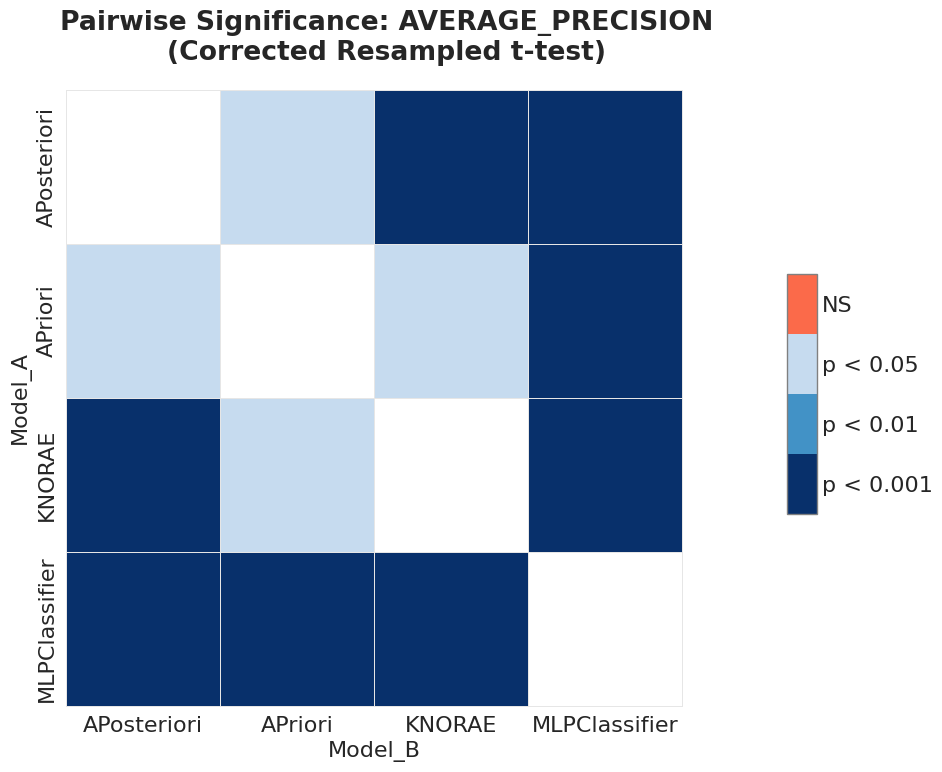

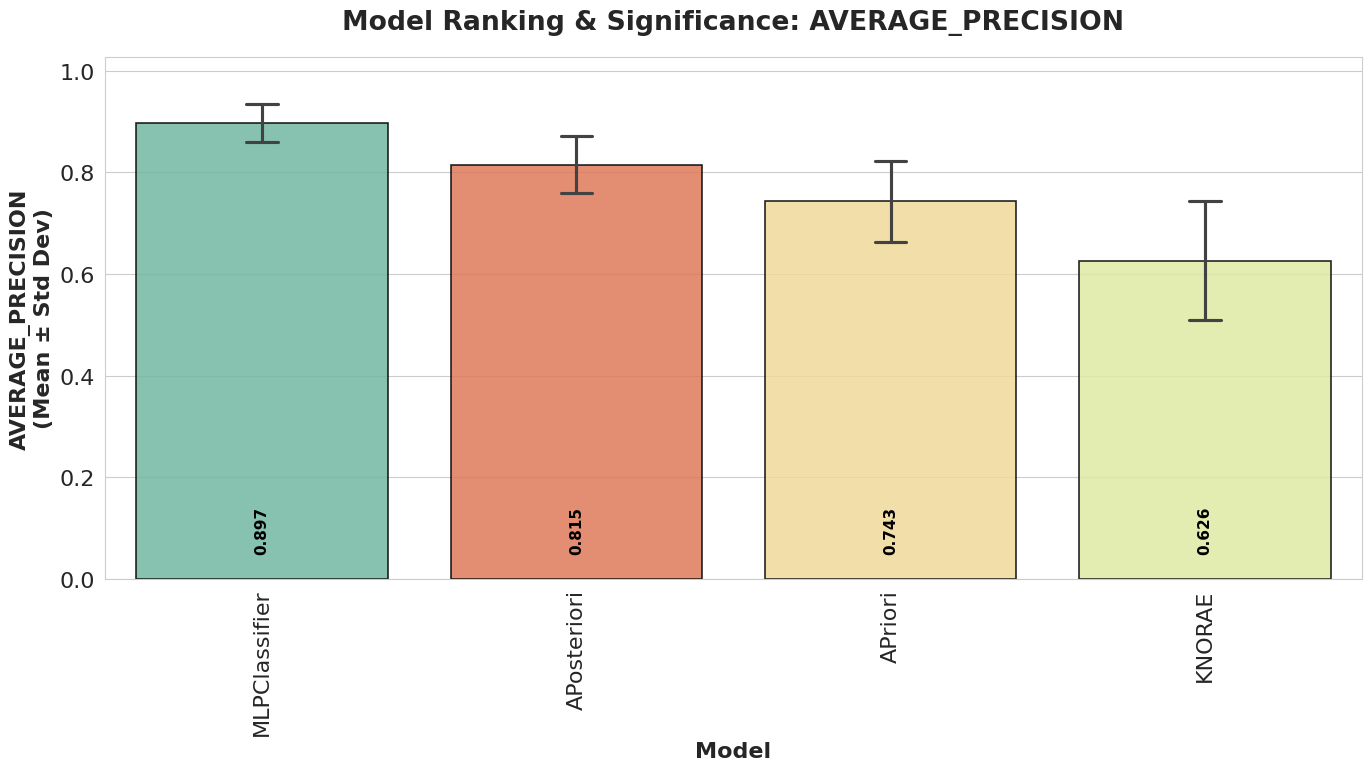


CORRECTED RESAMPLED t-TEST ANALYSIS (Pairwise): F1
Comparing 'APosteriori' (mean=0.748) vs 'APriori' (mean=0.523)
  p-value: 0.0000 (t=5.2040) -> Statistically SIGNIFICANT
--------------------------------------------------------------------------------
Comparing 'APosteriori' (mean=0.748) vs 'KNORAE' (mean=0.528)
  p-value: 0.0000 (t=5.1285) -> Statistically SIGNIFICANT
--------------------------------------------------------------------------------
Comparing 'APosteriori' (mean=0.748) vs 'MLPClassifier' (mean=0.890)
  p-value: 0.0001 (t=-4.0699) -> Statistically SIGNIFICANT
--------------------------------------------------------------------------------
Comparing 'APriori' (mean=0.523) vs 'APosteriori' (mean=0.748)
  p-value: 0.0000 (t=-5.2040) -> Statistically SIGNIFICANT
--------------------------------------------------------------------------------
Comparing 'APriori' (mean=0.523) vs 'KNORAE' (mean=0.528)
  p-value: 0.8833 (t=-0.1471) -> NOT significant
--------------------------

/home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Dynamic-Ensemble-Learning-for-Credit-Card-Fraud-Detection/fraud_dynamic_ensemble/evaluation/statistical_test_evaluation.py:314: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.sort_values(by=["model"], inplace=True)


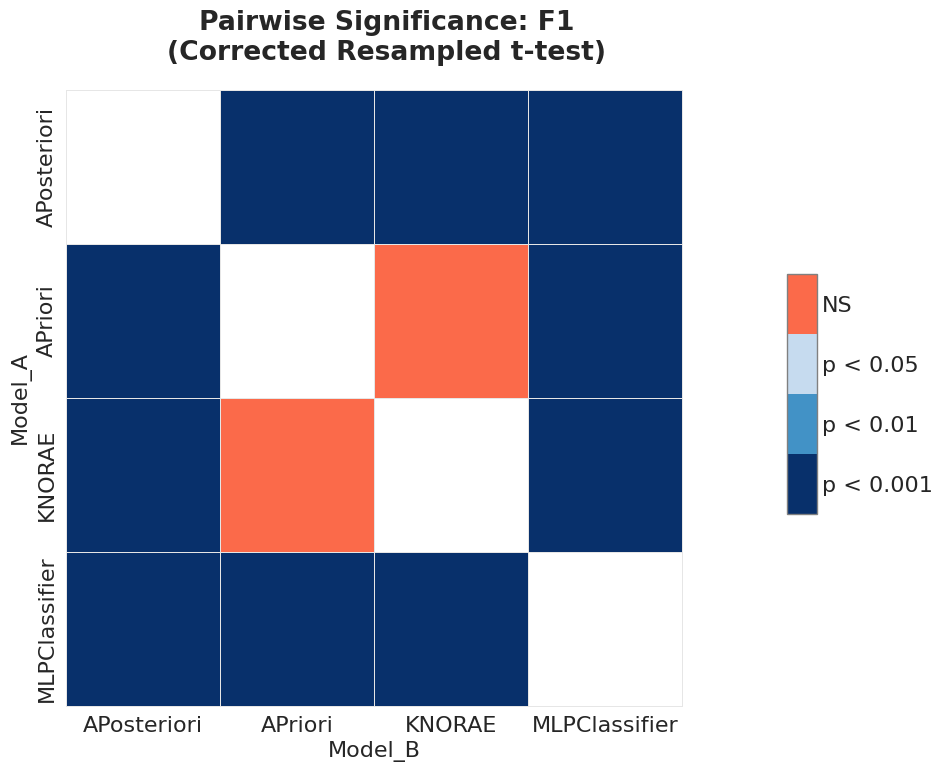

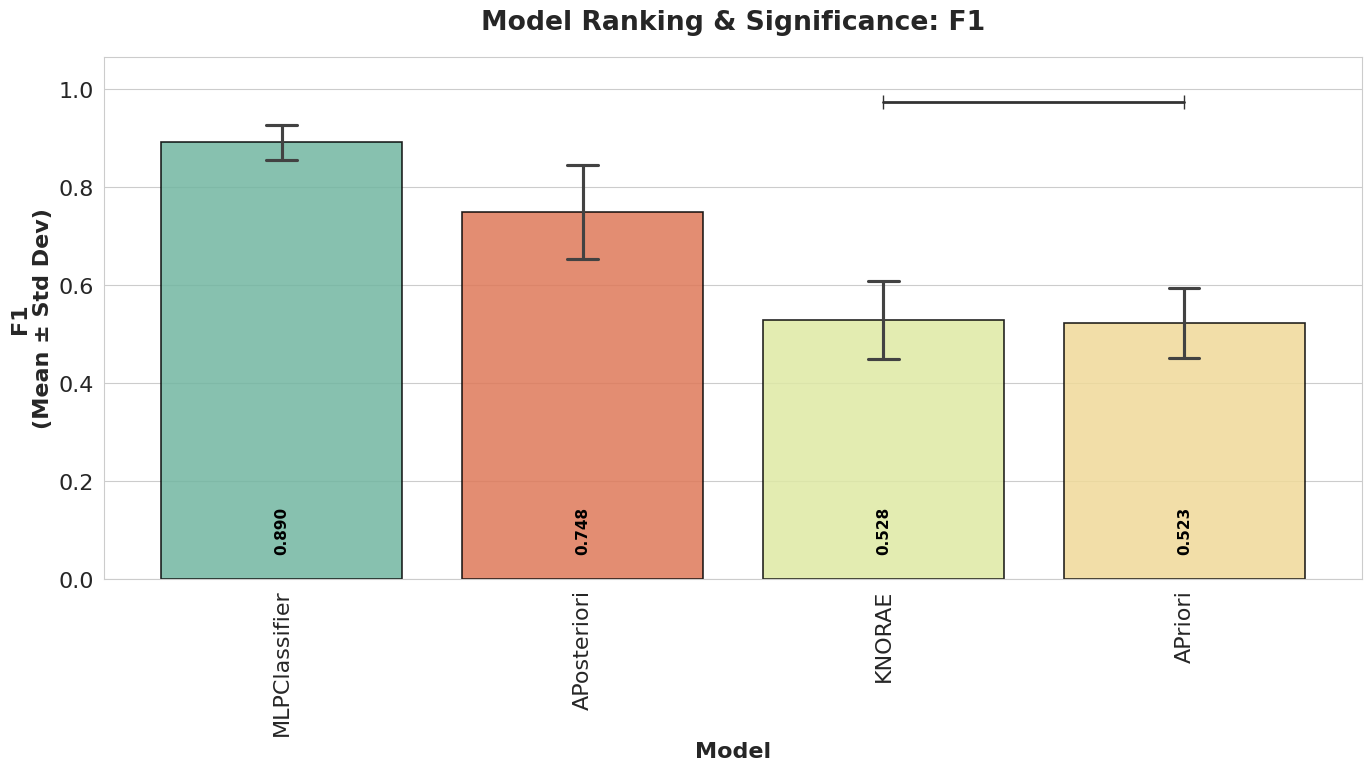


FINAL CORRECTED RESAMPLED t-TEST SUMMARY


,Metric,Model_A,Model_B,Mean_Diff,t-stat,p-value,is_significant,result
0,balanced_accuracy,APosteriori,APriori,0.013519,1.027430,3.067220e-01,False,No Diff
1,balanced_accuracy,APosteriori,KNORAE,0.013419,0.964683,3.370542e-01,False,No Diff
2,balanced_accuracy,APosteriori,MLPClassifier,-0.002750,-0.180059,8.574746e-01,False,No Diff
3,balanced_accuracy,APriori,APosteriori,-0.013519,-1.027430,3.067220e-01,False,No Diff
4,balanced_accuracy,APriori,KNORAE,-0.000100,-0.009953,9.920785e-01,False,No Diff
5,balanced_accuracy,APriori,MLPClassifier,-0.016269,-1.122939,2.641792e-01,False,No Diff
6,balanced_accuracy,KNORAE,APosteriori,-0.013419,-0.964683,3.370542e-01,False,No Diff
7,balanced_accuracy,KNORAE,APriori,0.000100,0.009953,9.920785e-01,False,No Diff
8,balanced_accuracy,KNORAE,MLPClassifier,-0.016169,-1.111885,2.688804e-01,False,No Diff
9,balanced_accuracy,MLPClassifier,APosteriori,0.002750,0.180059,8.574746e-01,False,No Diff


In [12]:
pairwise_frames = []

for metric in metrics_to_analyze:
    report = compute_pairwise_corrected_resampled_ttest(
        df=generalization_df,
        metric_name=metric, # Pass single string here
        n_train=0.9,
        n_test=0.1,
        save_path=FIGURES_MULTIPLE_MODELS_EVALUATION_DIR
    )

    if report is not None:
        pairwise_frames.append(report)

# --- Aggregate & Save Master CSV ---
if pairwise_frames:
    # Concatenate all metric-specific dataframes vertically (stacking rows)
    final_comparisons_df: pd.DataFrame = pd.concat(pairwise_frames, axis=0)

    print(f"\n{'='*80}\nFINAL CORRECTED RESAMPLED t-TEST SUMMARY\n{'='*80}")
    ipd.display(final_comparisons_df)

    # Define filename
    final_csv_path = FIGURES_MULTIPLE_MODELS_EVALUATION_DIR / "corrected_resampled_ttest_summary.csv"
    final_comparisons_df.to_csv(final_csv_path, index=False)
else:
    print("No pairwise comparisons were generated.")